In [38]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import statistics

In [ ]:
# Step 1: Read CSVs
reac5_iter18 = '/Users/aya/github/WWDR/ASM1-2d-3_MATLAB/ASM1 2d 3 in BSM1/ASM3/ASM3_OutputDB/noimnal/iter18/settler_data_DR_iteration_18.csv'
reac5_nominal18 = '/Users/aya/github/WWDR/ASM1-2d-3_MATLAB/ASM1 2d 3 in BSM1/ASM3/ASM3_OutputDB/nominal/iter18/settler_data_nominal_iteration_18.csv'

In [99]:
nominal = pd.read_csv(reac5_nominal18)
iteration = pd.read_csv(reac5_iter18)

# Step 2: Apply column labels
column_names = ['SIevec', 'SSevec', 'XIevec', 'XSevec', 'XBHevec', 'XBAevec', 'SOevec', 'SNOevec', 'SNHevec', 'SALKevec', 'TSSevec', 'EQvecinst_new', 'EQvec_new']
nominal.columns = column_names
iteration.columns = column_names

# Step 4: Add EQI series and moving average
for df in [nominal, iteration]:
    df["mR"] = df["EQvecinst_new"].rolling(window=96, min_periods=1).mean()
    df["tagS"] = 0
    df["tagF"] = 0

def compute_tags_relative(iteration_df, nominal_df):
    # Compute mean and std of nominal moving average from stable region
    iteration_df["series_diff"] = (iteration_df["EQvecinst_new"] - nominal_df["EQvecinst_new"]).clip(lower=0)
    series_diff_mean = statistics.mean(iteration_df["series_diff"])
    series_diff_std = statistics.pstdev(iteration_df["series_diff"])

    for i in range(len(iteration_df)):
        val = iteration_df.at[i, "series_diff"]
        if val > series_diff_mean + 2.5 * series_diff_std:
            iteration_df.at[i, "tagS"] = 4
        elif val > series_diff_mean + 2.0 * series_diff_std:
            iteration_df.at[i, "tagS"] = 3
        elif val > series_diff_mean + 1.5 * series_diff_std:
            iteration_df.at[i, "tagS"] = 2
        elif val > series_diff_mean + series_diff_std:
            iteration_df.at[i, "tagS"] = 1
        else:
            iteration_df.at[i, "tagS"] = 0

# Step 6: Compute TagF
def compute_tagF(df):
    for i in range(len(df)):
        s = df["tagS"]
        if i < 4:
            continue
        if s[i] == 4:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1:
                df.at[i, "tagF"] = 3
            else:
                df.at[i, "tagF"] = 2
        if s[i] == 3:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 3
            else:
                df.at[i, "tagF"] = 2
        elif s[i] == 2:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 4
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 2
            else:
                df.at[i, "tagF"] = 1
        elif s[i] == 1:
            if s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1 and s[i-4] >= 1:
                df.at[i, "tagF"] = 3
            elif s[i-1] >= 1 and s[i-2] >= 1 and s[i-3] >= 1:
                df.at[i, "tagF"] = 2
            elif s[i-1] >= 1 and s[i-2] >= 1:
                df.at[i, "tagF"] = 1
            else:
                df.at[i, "tagF"] = 1
        else:
            df.at[i, "tagF"] = 0

# Step 7: Compute TagR
# Define the 5x5 Risk Matrix (SEVERITY as rows, FREQUENCY as columns)
# Rows: Severity 0 → 4
# Cols: Frequency 0 → 4
risk_matrix = np.array([
    [0, 0, 0, 1, 2],  # Severity = 0
    [1, 1, 1, 2, 3],  # Severity = 1
    [1, 1, 2, 3, 4],  # Severity = 2
    [2, 2, 3, 4, 4],  # Severity = 3
    [2, 3, 3, 4, 4],  # Severity = 4
])

def get_tagR(severity, frequency):
    # Clamp values to valid range [0, 4] to prevent IndexError
    s = int(np.clip(severity, 0, 4))
    f = int(np.clip(frequency, 0, 4))
    return risk_matrix[s, f]

def assign_tagR(df):
    iteration["tagR"] = iteration.apply(lambda row: get_tagR(row["tagS"], row["tagF"]), axis=1)

compute_tags_relative(iteration, nominal)
compute_tagF(iteration)
assign_tagR(iteration)


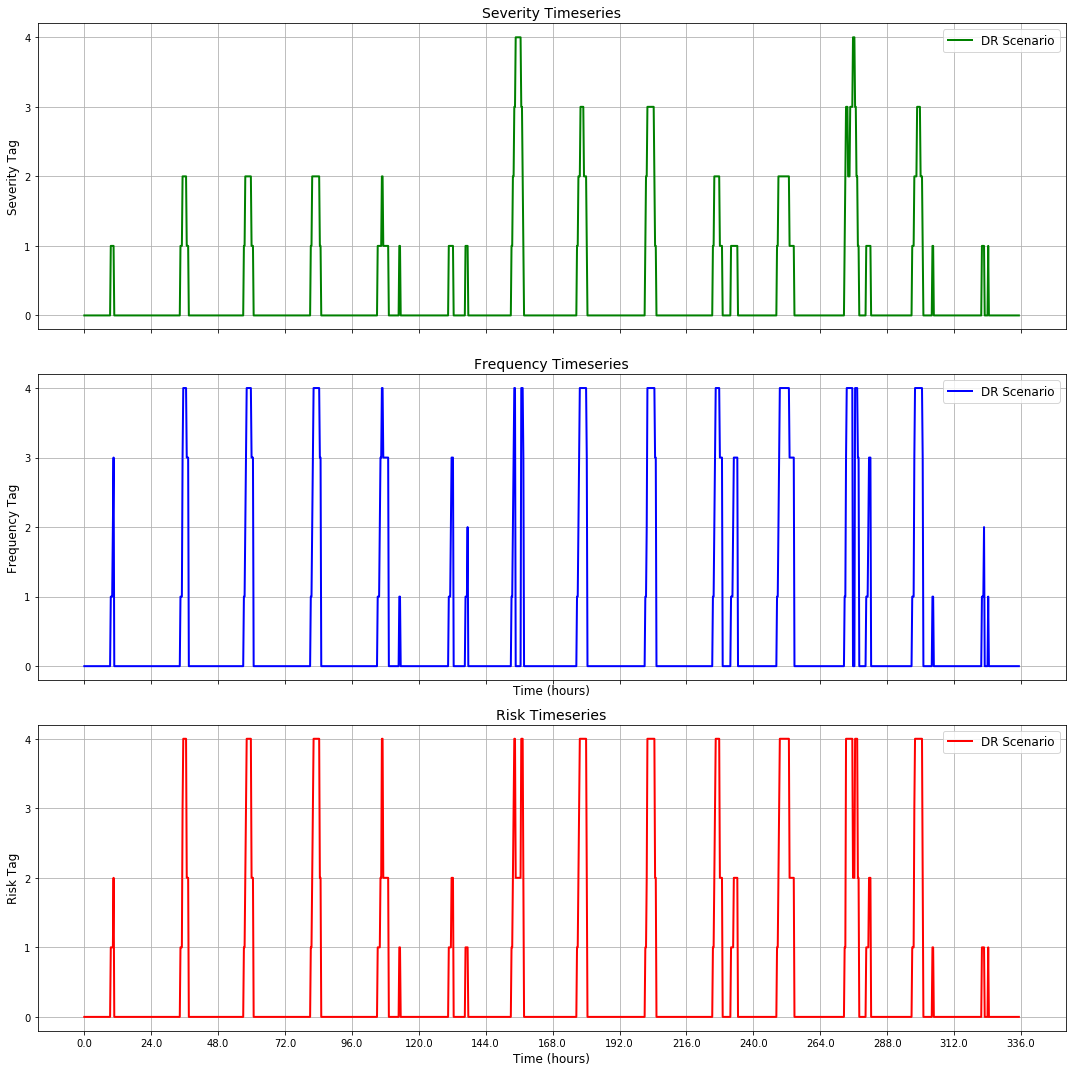

In [100]:
# Plotting script
fig, axs = plt.subplots(3, figsize=(15, 15), sharex=True)

# Common Y-axis ticks
ytick_interval = 1
yticks = range(0, 5, ytick_interval)

axs[0].plot(iteration["tagS"], label="DR Scenario", color="green", linewidth=2.0)
axs[0].legend(fontsize=12)
axs[0].set_ylabel("Severity Tag", fontsize=12)
axs[0].set_title("Severity Timeseries", fontsize=14)
axs[0].set_yticks(yticks)
axs[0].grid(True)

axs[1].plot(iteration["tagF"], label="DR Scenario", color="blue", linewidth=2.0)
axs[1].legend(fontsize=12)
axs[1].set_ylabel("Frequency Tag", fontsize=12)
axs[1].set_title("Frequency Timeseries", fontsize=14)
axs[1].set_yticks(yticks)
axs[1].grid(True)

axs[2].plot(iteration["tagR"], label="DR Scenario", color="red", linewidth=2.0)
axs[2].legend(fontsize=12)
axs[2].set_ylabel("Risk Tag", fontsize=12)
axs[2].set_title("Risk Timeseries", fontsize=14)
axs[2].set_yticks(yticks)
axs[2].grid(True)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

axs[1].set_xticks(range(0, total_steps + 1, xtick_interval))
axs[1].set_xticklabels([f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)], fontsize=12)
axs[1].set_xlabel("Time (hours)", fontsize=12)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=12)

# Larger legend font and enable grid
plt.tight_layout()
plt.show()

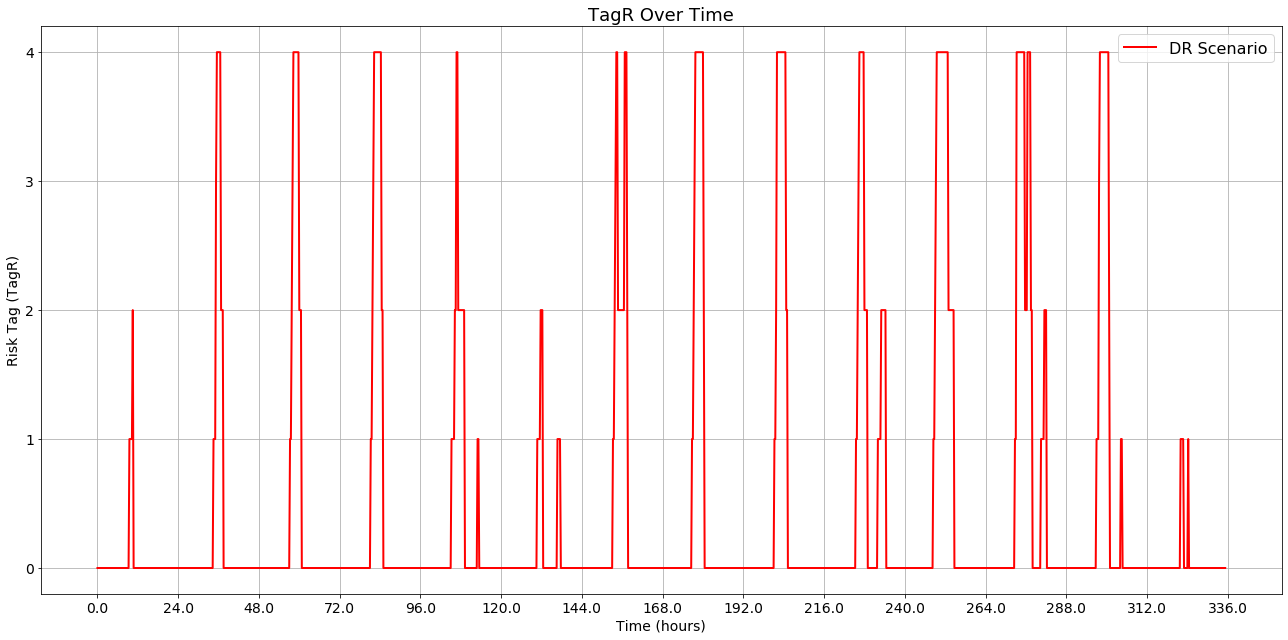

In [101]:
# Step 8: Plotting script
plt.figure(figsize=(18, 9))

plt.plot(iteration["tagR"], label="DR Scenario", color="red", linewidth=2.0)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps
ytick_interval = 1

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=14
)
plt.yticks(
    ticks=range(0, 5, ytick_interval),
    #labels=[f"{x * time_step_hr:.1f}" for x in range(0, 3, ytick_interval)],
    fontsize=14
)

# Labels and title with larger font
plt.xlabel("Time (hours)", fontsize=14)
plt.ylabel("Risk Tag (TagR)", fontsize=14)
plt.title("TagR Over Time", fontsize=18)

# Larger legend font and enable grid
plt.legend(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

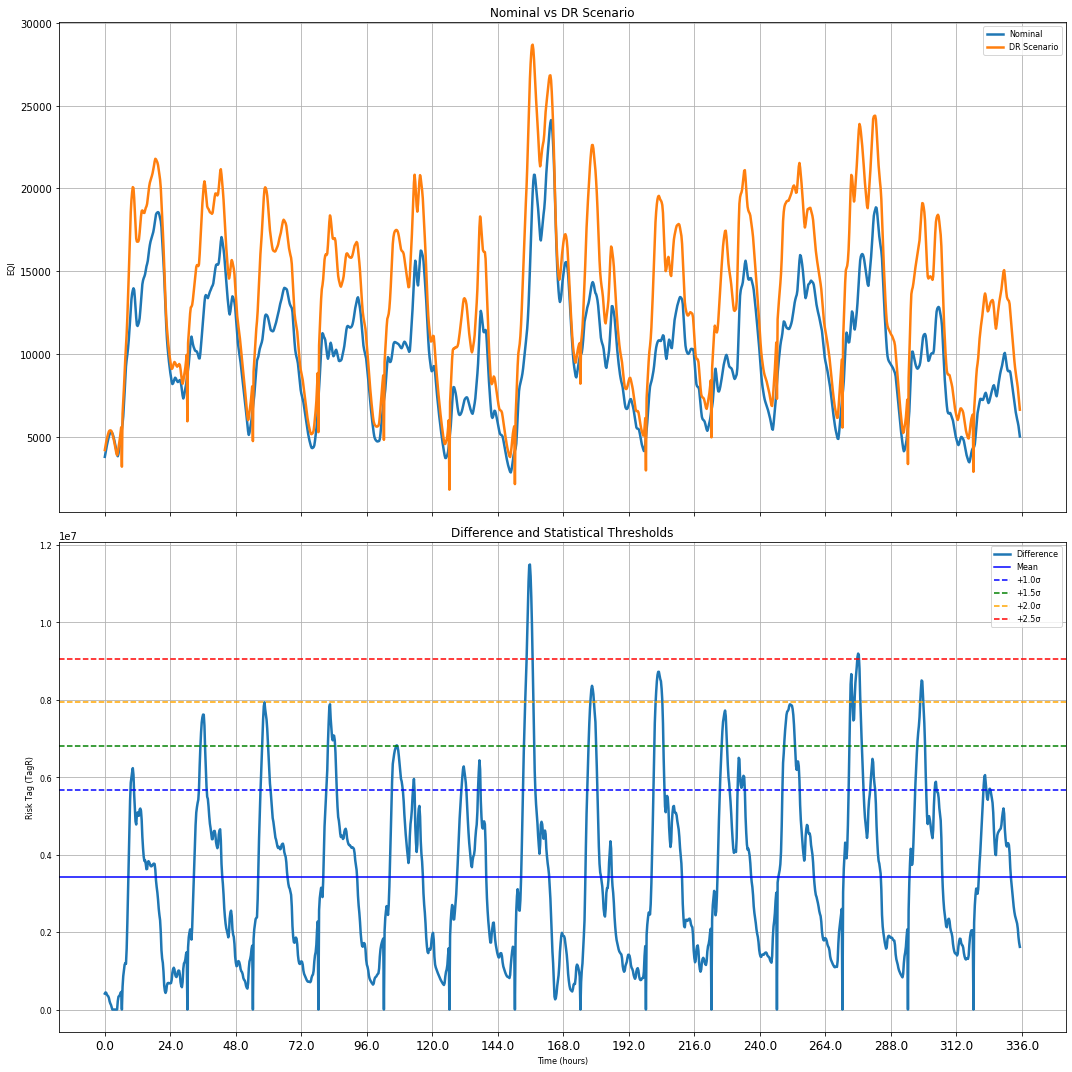

In [102]:
# Step 8: Modified Plotting Script
fig, axs = plt.subplots(2, figsize=(15, 15), sharex=True)

# First subplot: Nominal and Iteration series
axs[0].plot(nominal["EQvecinst_new"] / 1000, label="Nominal", linewidth=2.5)
axs[0].plot(iteration["EQvecinst_new"] / 1000, label="DR Scenario", linewidth=2.5)
axs[0].legend(fontsize=8)
axs[0].set_ylabel("EQI", fontsize=8)
axs[0].set_title("Nominal vs DR Scenario", fontsize=12)
axs[0].grid(True)

# Second subplot: Difference and statistical lines
axs[1].plot(iteration["series_diff"], label="Difference", linewidth=2.5)
axs[1].axhline(statistics.mean(iteration["series_diff"]), color='blue', label='Mean')
axs[1].axhline(statistics.mean(iteration["series_diff"]) + 1.0 * statistics.pstdev(iteration["series_diff"]), color='blue', linestyle='dashed', label='+1.0σ')
axs[1].axhline(statistics.mean(iteration["series_diff"]) + 1.5 * statistics.pstdev(iteration["series_diff"]), color='green', linestyle='dashed', label='+1.5σ')
axs[1].axhline(statistics.mean(iteration["series_diff"]) + 2.0 * statistics.pstdev(iteration["series_diff"]), color='orange', linestyle='dashed', label='+2.0σ')
axs[1].axhline(statistics.mean(iteration["series_diff"]) + 2.5 * statistics.pstdev(iteration["series_diff"]), color='red', linestyle='dashed', label='+2.5σ')
axs[1].legend(fontsize=8)
axs[1].set_ylabel("Risk Tag (TagR)", fontsize=8)
axs[1].set_title("Difference and Statistical Thresholds", fontsize=12)
axs[1].grid(True)

# Set up time axis in hours
total_steps = 1344
time_step_hr = 0.25
xtick_interval = 96  # every 12 hours → 12 / 0.25 = 48 steps

plt.xticks(
    ticks=range(0, total_steps + 1, xtick_interval),
    labels=[f"{x * time_step_hr:.1f}" for x in range(0, total_steps + 1, xtick_interval)],
    fontsize=12
)
plt.xlabel("Time (hours)", fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()


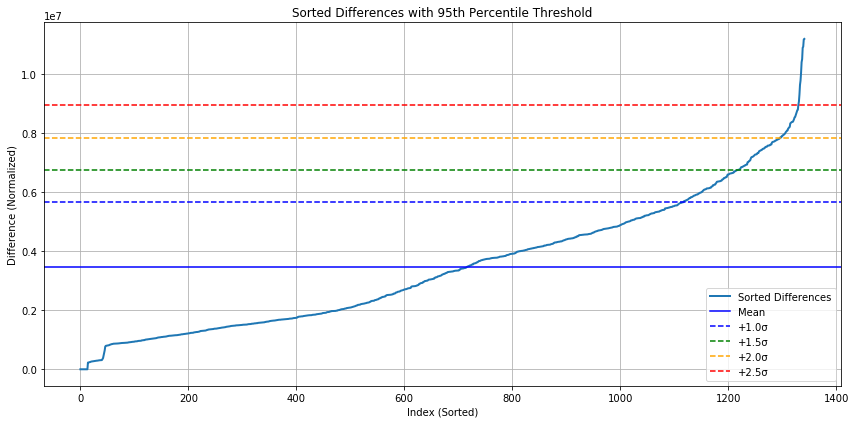

In [13]:
# Sort the series by value (magnitude)
sorted_diff = iteration["series_diff"].sort_values().reset_index(drop=True)

# Calculate the 95th percentile
percentile_95 = sorted_diff.quantile(0.95)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sorted_diff, label="Sorted Differences", linewidth=2.0)
#plt.axhline(percentile_95, color='black', linestyle='dashed', label="95th Percentile")
plt.axhline(statistics.mean(iteration["series_diff"]), color='blue', label='Mean')
plt.axhline(statistics.mean(iteration["series_diff"]) + 1.0 * statistics.pstdev(iteration["series_diff"]), color='blue', linestyle='dashed', label='+1.0σ')
plt.axhline(statistics.mean(iteration["series_diff"]) + 1.5 * statistics.pstdev(iteration["series_diff"]), color='green', linestyle='dashed', label='+1.5σ')
plt.axhline(statistics.mean(iteration["series_diff"]) + 2.0 * statistics.pstdev(iteration["series_diff"]), color='orange', linestyle='dashed', label='+2.0σ')
plt.axhline(statistics.mean(iteration["series_diff"]) + 2.5 * statistics.pstdev(iteration["series_diff"]), color='red', linestyle='dashed', label='+2.5σ')

# Labeling
plt.xlabel("Index (Sorted)", fontsize=10)
plt.ylabel("Difference (Normalized)", fontsize=10)
plt.title("Sorted Differences with 95th Percentile Threshold", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


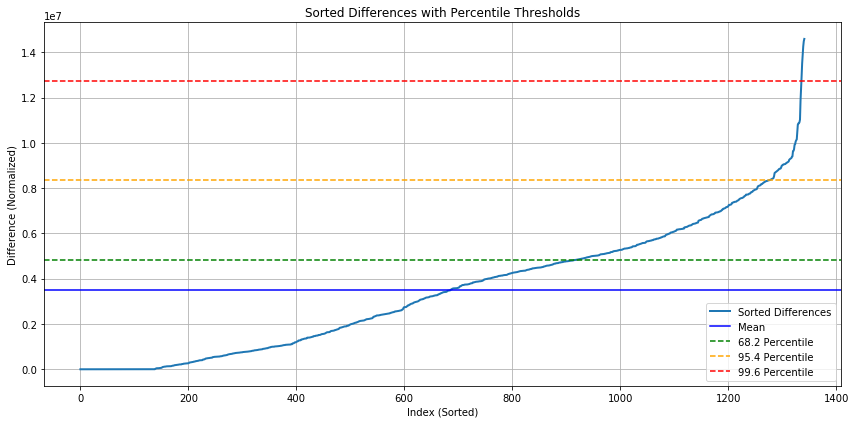

In [50]:
# Sort the series by value (magnitude)
sorted_diff = iteration["series_diff"].sort_values().reset_index(drop=True)

# Calculate the percentiles
percentile_682 = sorted_diff.quantile(0.682)
percentile_95 = sorted_diff.quantile(0.95)
percentile_996 = sorted_diff.quantile(0.996)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(sorted_diff, label="Sorted Differences", linewidth=2.0)
plt.axhline(statistics.mean(iteration["series_diff"]), color='blue', label='Mean')
plt.axhline(percentile_682, color='green', linestyle='dashed', label="68.2 Percentile")
plt.axhline(percentile_95, color='orange', linestyle='dashed', label="95.4 Percentile")
plt.axhline(percentile_996, color='red', linestyle='dashed', label="99.6 Percentile")

# Labeling
plt.xlabel("Index (Sorted)", fontsize=10)
plt.ylabel("Difference (Normalized)", fontsize=10)
plt.title("Sorted Differences with Percentile Thresholds", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()
